### Inventory Recommendation Rule

For the inventory assistant, I assume a 2-day supplier lead time and a 20% safety buffer.

Recommended order quantity:

`max(0, forecast × lead_time × (1 + safety_stock) - current_inventory)`

A product is flagged as `HIGH` stockout risk when current inventory is below the next-day forecast.

These parameters are business assumptions and should ideally be configurable in a production system.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [11]:
df = pd.read_csv("./Data/processed_csv_dataset.csv")
print("Shape:", df.shape)

display(df.head())

Shape: (76000, 26)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,year,month,day,day_of_week,week_of_year,is_weekend,dow_sin,dow_cos,month_sin,month_cos
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,5,52,1,-0.974928,-0.222521,0.5,0.866025
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,5,52,1,-0.974928,-0.222521,0.5,0.866025
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,5,52,1,-0.974928,-0.222521,0.5,0.866025
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,5,52,1,-0.974928,-0.222521,0.5,0.866025
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,5,52,1,-0.974928,-0.222521,0.5,0.866025


In [22]:
target = "Demand"

categorical_features = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

numeric_features = [
    "Price",
    "Discount",
    "Promotion",
    "Competitor Pricing",
    "Epidemic",

    "demand_lag_1",
    "demand_lag_7",
    "demand_lag_14",
    "demand_lag_28",

    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_std_7",

    "day_of_week",
    "month",
    "day",
    "week_of_year",
    "is_weekend",

    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

features = categorical_features + numeric_features

In [14]:
df["Date"] = pd.to_datetime(df["Date"])

latest_date = df["Date"].max()

latest_rows = (
    df[df["Date"] == latest_date]
    .copy()
)

print("Latest date:", latest_date)
print("Rows:", len(latest_rows))

Latest date: 2024-01-30 00:00:00
Rows: 100


In [15]:
future_rows = latest_rows.copy()

future_rows["Date"] = (
    future_rows["Date"] +
    pd.Timedelta(days=1)
)

future_rows["Demand"] = np.nan

# future lag features

In [16]:
historical = df.copy()

combined = pd.concat(
    [historical, future_rows],
    ignore_index=True,
    sort=False
)

combined = combined.sort_values(
    ["Store ID", "Product ID", "Date"]
).reset_index(drop=True)

In [18]:
group = combined.groupby(
    ["Store ID", "Product ID"]
)["Demand"]

for lag in [1, 7, 14, 28]:
    combined[f"demand_lag_{lag}"] = group.shift(lag)

In [19]:
# Rolling features
combined["rolling_mean_7"] = (
    combined
    .groupby(["Store ID", "Product ID"])["Demand"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

combined["rolling_mean_14"] = (
    combined
    .groupby(["Store ID", "Product ID"])["Demand"]
    .transform(
        lambda x: x.shift(1).rolling(14).mean()
    )
)

combined["rolling_std_7"] = (
    combined
    .groupby(["Store ID", "Product ID"])["Demand"]
    .transform(
        lambda x: x.shift(1).rolling(7).std()
    )
)

In [20]:
# Date features:
combined["year"] = combined["Date"].dt.year
combined["month"] = combined["Date"].dt.month
combined["day"] = combined["Date"].dt.day
combined["day_of_week"] = combined["Date"].dt.dayofweek
combined["week_of_year"] = (
    combined["Date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

combined["is_weekend"] = (
    combined["day_of_week"] >= 5
).astype(int)

combined["dow_sin"] = np.sin(
    2 * np.pi * combined["day_of_week"] / 7
)

combined["dow_cos"] = np.cos(
    2 * np.pi * combined["day_of_week"] / 7
)

combined["month_sin"] = np.sin(
    2 * np.pi * combined["month"] / 12
)

combined["month_cos"] = np.cos(
    2 * np.pi * combined["month"] / 12
)

# Predict tomorrow's demand

In [24]:
import joblib

forecast_model = joblib.load("models/xgboost_model.pkl")

In [25]:
future_date = latest_date + pd.Timedelta(days=1)

future_model_data = combined[
    combined["Date"] == future_date
].copy()

future_X = future_model_data[features]

future_predictions = forecast_model.predict(
    future_X
)

future_model_data["Forecast Demand"] = (
    future_predictions
)

In [26]:
recommendations = future_model_data[
    [
        "Store ID",
        "Product ID",
        "Category",
        "Region",
        "Inventory Level",
        "Forecast Demand"
    ]
].copy()

In [27]:
LEAD_TIME_DAYS = 2
SAFETY_STOCK_PERCENT = 0.20

In [28]:
recommendations["Stockout Risk"] = (
    recommendations["Inventory Level"] <
    recommendations["Forecast Demand"]
)

# Recommended order:

In [29]:
recommendations["Recommended Order"] = np.maximum(
    0,
    np.ceil(
        recommendations["Forecast Demand"]
        * LEAD_TIME_DAYS
        * (1 + SAFETY_STOCK_PERCENT)
        - recommendations["Inventory Level"]
    )
).astype(int)

# Priority:

In [30]:
recommendations["Priority"] = np.where(
    recommendations["Stockout Risk"],
    "HIGH",
    np.where(
        recommendations["Recommended Order"] > 0,
        "MEDIUM",
        "LOW"
    )
)

#  Round forecast:

In [31]:
recommendations["Forecast Demand"] = (
    recommendations["Forecast Demand"]
    .round(1)
)

In [32]:
urgent_items = (
    recommendations
    .sort_values(
        ["Stockout Risk", "Recommended Order"],
        ascending=[False, False]
    )
)

display(
    urgent_items.head(20)
)

,Store ID,Product ID,Category,Region,Inventory Level,Forecast Demand,Stockout Risk,Recommended Order,Priority
44898,S003,P0019,Groceries,East,108,135.300003,True,217,HIGH
28917,S002,P0018,Clothing,South,61,112.099998,True,209,HIGH
38810,S003,P0011,Electronics,East,143,143.399994,True,202,HIGH
37288,S003,P0009,Groceries,East,123,124.300003,True,176,HIGH
38049,S003,P0010,Groceries,East,111,119.199997,True,176,HIGH
21307,S002,P0008,Groceries,South,85,102.500000,True,161,HIGH
32722,S003,P0003,Electronics,East,95,105.099998,True,158,HIGH
19785,S002,P0006,Clothing,South,98,102.599998,True,149,HIGH
9892,S001,P0013,Toys,North,91,95.400002,True,139,HIGH
27395,S002,P0016,Clothing,South,88,90.300003,True,129,HIGH


# Inventory Summary

In [33]:
print(
    "Products at stockout risk:",
    recommendations["Stockout Risk"].sum()
)

print(
    "Total products:",
    len(recommendations)
)

print(
    "Total recommended units to order:",
    recommendations["Recommended Order"].sum()
)

Products at stockout risk: 11
Total products: 100
Total recommended units to order: 4939


In [34]:
display(
    recommendations[
        recommendations["Stockout Risk"]
    ].sort_values(
        "Forecast Demand",
        ascending=False
    )
)

,Store ID,Product ID,Category,Region,Inventory Level,Forecast Demand,Stockout Risk,Recommended Order,Priority
38810,S003,P0011,Electronics,East,143,143.399994,True,202,HIGH
44898,S003,P0019,Groceries,East,108,135.300003,True,217,HIGH
37288,S003,P0009,Groceries,East,123,124.300003,True,176,HIGH
38049,S003,P0010,Groceries,East,111,119.199997,True,176,HIGH
28917,S002,P0018,Clothing,South,61,112.099998,True,209,HIGH
32722,S003,P0003,Electronics,East,95,105.099998,True,158,HIGH
19785,S002,P0006,Clothing,South,98,102.599998,True,149,HIGH
21307,S002,P0008,Groceries,South,85,102.500000,True,161,HIGH
9892,S001,P0013,Toys,North,91,95.400002,True,139,HIGH
27395,S002,P0016,Clothing,South,88,90.300003,True,129,HIGH


# A simple inventory chart

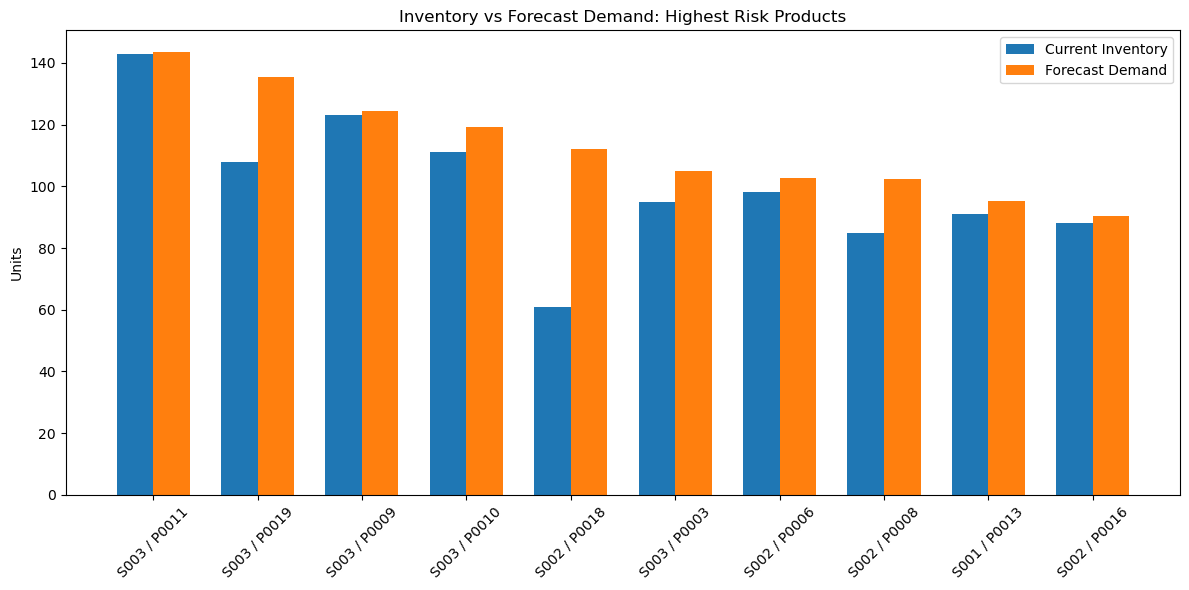

In [37]:
top_risk = (
    recommendations[
        recommendations["Stockout Risk"]
    ]
    .sort_values(
        "Forecast Demand",
        ascending=False
    )
    .head(10)
)

labels = (
    top_risk["Store ID"] +
    " / " +
    top_risk["Product ID"]
)

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    top_risk["Inventory Level"],
    width,
    label="Current Inventory"
)

plt.bar(
    x + width/2,
    top_risk["Forecast Demand"],
    width,
    label="Forecast Demand"
)

plt.xticks(
    x,
    labels,
    rotation=45
)

plt.ylabel("Units")
plt.title("Inventory vs Forecast Demand: Highest Risk Products")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
recommendations.to_csv(
    "./Plots/inventory_recommendations.csv",
    index=False
)

print("Saved inventory_recommendations.csv")

Saved inventory_recommendations.csv
